# Домашнее задание №2

Тема "Доверительные интервалы"

Общие положения:
- Макс кол-во баллов за ДЗ - 25 баллов
- Качество оформления и кода играет роль

Список заданий:
1.



In [1]:
import pandas as pd
import numpy as np

from scipy import stats

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('ggplot')
%matplotlib inline

In [2]:
# задаём стандартное нормальное распределение
norm_distr = stats.norm(loc=0, scale=1)

# рассчитываем квантиль по заданному уровню значимости
alpha = 0.05
z = norm_distr.ppf(alpha/2)
print(z)

-1.9599639845400545


## Задание 1  
Компания утверждает, что длина шнурков в партии обуви имеет среднее значение 120 см, и стандартное отклонение в партии точно известно и составляет 5 см. Из выборки 25 шнурков было получено среднее значение длины 122 см. Найдите 99%-ый доверительный интервал для среднего значения длины шнурков (1 балл)

In [ ]:
sample_mean = 122  
sigma = 5          
n = 25             
confidence_level = 0.99

sem = sigma / np.sqrt(n)

z = stats.norm.ppf((1 + confidence_level) / 2)

margin_of_error = z * sem

lower_bound = sample_mean - margin_of_error
upper_bound = sample_mean + margin_of_error

print(f"99%-ный доверительный интервал: ({lower_bound:.3f}, {upper_bound:.3f})")

99%-ный доверительный интервал: (119.424, 124.576)


## Задание 2
Компания исследует среднее время выполнения заказа курьерской службой. Было случайным образом выбрано 10 заказов, для которых среднее время доставки составило 45 минут, а выборочная дисперсия — 9 минут. Постройте 95%-ый доверительный интервал для среднего времени доставки заказа (1 балл)

In [4]:
sample_mean = 45
sample_variance = 9
n = 10
confidence_level = 0.95

sample_std_dev = np.sqrt(sample_variance)

degrees_of_freedom = n - 1
t_critical = stats.t.ppf((1 + confidence_level) / 2, degrees_of_freedom)

sem = sample_std_dev / np.sqrt(n)

margin_of_error = t_critical * sem

lower_bound = sample_mean - margin_of_error
upper_bound = sample_mean + margin_of_error

print(f"{confidence_level * 100 :.0f}%-ный доверительный интервал: ({lower_bound:.2f}, {upper_bound:.2f})")

95%-ный доверительный интервал: (42.85, 47.15)


## Задание 3
Интернет-магазин хочет определить долю пользователей, которые возвращаются для повторной покупки в течение месяца после первой покупки. Для этого он проанализировал выборку из 800 клиентов, и оказалось, что 240 из них сделали повторную покупку в течение месяца. Необходимо определить 95% доверительный интервал для истинной доли клиентов, которые возвращаются для повторной покупки в течение этого времени (1 балл)


In [5]:
n = 800
x = 240

alpha = 0.05

p_hat = x / n

z = stats.norm.ppf(1 - alpha / 2)

margin_of_error = z * np.sqrt((p_hat * (1 - p_hat)) / n)

lower_bound = p_hat - margin_of_error
upper_bound = p_hat + margin_of_error

print(f"95%-ый доверительный интервал для истинной доли: ({lower_bound:.4f}, {upper_bound:.4f})")

95%-ый доверительный интервал для истинной доли: (0.2682, 0.3318)


## Задание 4
Два студента Тимофей и Пётр решают задачи из учебника по статистике, каждый со своей усердностью λ (количество решенных задач в день).
Тимофей считает себя более усердным студентом. Необходимо построить доверительный для разности λ1 - λ2 и проверить, правда ли это.
Студенты решают задачи независимо друг от друга (1 балл)

In [6]:
a = [7, 5, 2, 8, 4, 9, 2, 6, 6, 7] # Тимофей
b = [3, 3, 3, 9, 9, 2, 2, 2, 2, 9] # Пётр

In [7]:
alpha = .05

mean_a = np.mean(a)
mean_b = np.mean(b)

var_a = np.var(a, ddof=1)
var_b = np.var(b, ddof=1)

n_a = len(a)
n_b = len(b)

difference = mean_a - mean_b

se_difference = np.sqrt((var_a / n_a) + (var_b / n_b))

df = min(n_a - 1, n_b - 1)

t_critical = stats.t.ppf(1 - alpha / 2, df)

margin_of_error = t_critical * se_difference
lower_bound = difference - margin_of_error
upper_bound = difference + margin_of_error

print(f"Средняя усердность Тимофея: {mean_a:.2f}")
print(f"Средняя усердность Петра: {mean_b:.2f}")
print(f"Разность усердностей (Тимофей - Пётр): {difference:.2f}")
print(f"95%-ый доверительный интервал для разности: ({lower_bound:.2f}, {upper_bound:.2f})")

if lower_bound > 0:
    print("Тимофей действительно более усерден.")
else:
    print("Нет оснований утверждать, что Тимофей более усерден.")

Средняя усердность Тимофея: 5.60
Средняя усердность Петра: 4.40
Разность усердностей (Тимофей - Пётр): 1.20
95%-ый доверительный интервал для разности: (-1.65, 4.05)
Нет оснований утверждать, что Тимофей более усерден.


## Задания 5-8 (5 баллов всего)

In [8]:
!curl -O https://raw.githubusercontent.com/practical-jupyter/sample-data/refs/heads/master/anime/anime.csv >> anime.csv

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100  778k  100  778k    0     0  1550k      0 --:--:-- --:--:-- --:--:-- 1554k


Описание датафрейма:
- `anime_id` - ID
- `name` - название
- `genre` - жанр (строка с пречисление через запятую)
- `type` - формат
- `episodes` - кол-во эпизодов
- `rating` - средний рейтинг
- `members` - кол-во смотрящих

In [9]:
df_anime = pd.read_csv('anime.csv')
df_anime.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10486 entries, 0 to 10485
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   anime_id  10486 non-null  int64  
 1   name      10486 non-null  object 
 2   genre     10424 non-null  object 
 3   type      10463 non-null  object 
 4   episodes  10486 non-null  object 
 5   rating    10275 non-null  float64
 6   members   10486 non-null  int64  
dtypes: float64(1), int64(2), object(4)
memory usage: 573.6+ KB


In [10]:
df_anime.head(10)

,anime_id,name,genre,type,episodes,rating,members
0,32281,Kimi no Na wa.,"Drama, Romance, School, Supernatural",Movie,1,9.37,200630
1,5114,Fullmetal Alchemist: Brotherhood,"Action, Adventure, Drama, Fantasy, Magic, Mili...",TV,64,9.26,793665
2,28977,Gintama°,"Action, Comedy, Historical, Parody, Samurai, S...",TV,51,9.25,114262
3,9253,Steins;Gate,"Sci-Fi, Thriller",TV,24,9.17,673572
4,9969,Gintama&#039;,"Action, Comedy, Historical, Parody, Samurai, S...",TV,51,9.16,151266
5,32935,Haikyuu!!: Karasuno Koukou VS Shiratorizawa Ga...,"Comedy, Drama, School, Shounen, Sports",TV,10,9.15,93351
6,11061,Hunter x Hunter (2011),"Action, Adventure, Shounen, Super Power",TV,148,9.13,425855
7,820,Ginga Eiyuu Densetsu,"Drama, Military, Sci-Fi, Space",OVA,110,9.11,80679
8,15335,Gintama Movie: Kanketsu-hen - Yorozuya yo Eien...,"Action, Comedy, Historical, Parody, Samurai, S...",Movie,1,9.10,72534
9,15417,Gintama&#039;: Enchousen,"Action, Comedy, Historical, Parody, Samurai, S...",TV,13,9.11,81109


## 5. Постройте доверительный интервал для среднего рейтинга по всем аниме (1 балл)

In [11]:
def confidence_interval(data: pd.Series, alpha: float = 0.05) -> tuple[float, float]:
    n = len(data)
    mean = np.mean(data)
    std = np.std(data)
    z = stats.norm.ppf(1 - alpha / 2)
    
    margin_of_error = z * (std / np.sqrt(n))
    lower_bound = mean - margin_of_error
    upper_bound = mean + margin_of_error
    
    return float(lower_bound), float(upper_bound)


In [12]:
print(f"95%-ный доверительный интервал rating: {confidence_interval(df_anime['rating'])}" )

95%-ный доверительный интервал rating: (6.473485936738026, 6.5143116301719495)


## 6. Постройте доверительные интервалы для средних рейтингов по жанрам  (1 балл)

In [13]:
flatten = df_anime['genre'].str.split(', ').dropna().explode()
flatten = pd.concat([df_anime["rating"].loc[flatten.index], flatten], axis=1)
flatten.dropna(inplace=True)

interval_by_genre = flatten.groupby("genre").agg(confidence_interval)["rating"]
interval_by_genre.sort_values(ascending=False).head(15)

genre
Josei              (7.234537327866837, 7.65161651828701)
Mystery           (7.179382161669015, 7.329056656896385)
Thriller          (7.153818585716174, 7.610832577074527)
Police            (7.042257467277879, 7.275894706635165)
Shoujo Ai        (7.0408392795333725, 7.353307061930041)
Shounen           (7.018672102417514, 7.101724570647105)
Romance          (7.0185626839019815, 7.110018630976912)
Supernatural      (6.974408636651808, 7.101284029238763)
School           (6.963956892622217, 7.0685887572166655)
Drama             (6.954072929528669, 7.034225957593746)
Military          (6.934002823817984, 7.108861626309894)
Seinen           (6.9282662900802245, 7.095937249742783)
Psychological     (6.89927710807882, 7.1990639057460655)
Harem             (6.898492600615672, 7.091225709243483)
Super Power       (6.846088578588254, 7.027426272896894)
Name: rating, dtype: object

## 7. Постройте доверительные интервалы среднего рейтинга по типам аниме (1 балл)

In [14]:
interval_by_type = df_anime[["rating", "type"]].dropna().groupby("type").agg(confidence_interval)["rating"]
interval_by_type.sort_values(ascending=False)

type
TV          (6.870726757910306, 6.929570358314569)
Special     (6.477554303816609, 6.569313719820949)
OVA         (6.432844204007759, 6.515271438738756)
Movie       (6.261967319675294, 6.362025597544714)
ONA          (5.54546939918664, 5.721124007406768)
Music      (5.4992645581006885, 5.669253960417829)
Name: rating, dtype: object

## 8. По доверительным интервалам для episodes, rating и members оцените количество аномалий (2 балла)

In [15]:
rating = df_anime['rating'].dropna()
episodes = df_anime['episodes'].replace('Unknown', np.nan).astype(float).dropna()
members = df_anime['members'].dropna()

rating_interval = confidence_interval(rating)
episodes_interval = confidence_interval(episodes)
members_interval = confidence_interval(members)

In [16]:
anomaly_by_rating = (rating < rating_interval[0]) | (rating > rating_interval[1])
anomaly_by_episodes = (episodes < episodes_interval[0]) | (episodes > episodes_interval[1])
anomaly_by_members = (members < members_interval[0]) | (members > rating_interval[1])

In [ ]:
total_anomaly = (anomaly_by_episodes | anomaly_by_members | anomaly_by_rating).value_counts()

print(f"Количество аномалий по доверительным интервалам: {total_anomaly[True]}")

Количество аномалий по доверительным интервалам: 10346


## Задания 9-15. Продуктовые метрики (16 баллов всего)

In [18]:
!curl -O https://raw.githubusercontent.com/alina-zhu/datasets/refs/heads/master/customer_shopping_data.csv >> customer_shopping_data.csv

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100 6410k  100 6410k    0     0  7878k      0 --:--:-- --:--:-- --:--:-- 7884k


Описание датафрейма:
- `invoice_no` - номер чека
- `customer_id` - id клиента
- `gender` - пол клиента
- `age` - возраст клиента
- `category` - категория товара
- `quantity` - количество единиц товаров в чеке
- `price` - цена товара
- `payment_method` - метод оплаты
- `invoice_date` - дата покупки


In [19]:
df = pd.read_csv('customer_shopping_data.csv')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99457 entries, 0 to 99456
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   invoice_no      99457 non-null  object 
 1   customer_id     99457 non-null  object 
 2   gender          99457 non-null  object 
 3   age             99457 non-null  int64  
 4   category        99457 non-null  object 
 5   quantity        99457 non-null  int64  
 6   price           99457 non-null  float64
 7   payment_method  99457 non-null  object 
 8   invoice_date    99457 non-null  object 
dtypes: float64(1), int64(2), object(6)
memory usage: 6.8+ MB


In [20]:
df.head()

,invoice_no,customer_id,gender,age,category,quantity,price,payment_method,invoice_date
0,I138884,upeszhn26j,Female,28,Clothing,5,1500.40,Credit Card,2022-08-05
1,I317333,nyyoavbmge,Male,21,Shoes,3,1800.51,Debit Card,2021-12-12
2,I127801,iksbmqrtj0,Male,20,Clothing,1,300.08,Cash,2021-11-09
3,I173702,zfhc107gzu,Female,66,Shoes,5,3000.85,Credit Card,2021-05-16
4,I337046,diwrquryyt,Female,53,Books,4,60.60,Cash,2021-10-24


## 9. Посчитайте доверительный интервал для среднего возраста покупателей (1 балл)

In [21]:
from typing import Any

def some(data: pd.Series) -> Any:
    if len(data) == 0:
        return np.nan
    
    return data.iloc[0]

print(f"95%-ый доверительный интервал для среднего возраста покупателей: {confidence_interval(df[['customer_id', 'age']].groupby('customer_id').agg(some)['age'])}")

95%-ый доверительный интервал для среднего возраста покупателей: (43.259475025792185, 43.52970407868543)


## 10. Посчитайте доверительные интервалы для среднего чека в каждой категории (1 балл)

In [ ]:
df[['price', 'category']].groupby('category').agg(['mean', confidence_interval])

price                                          
                        mean                       confidence_interval
category                                                              
Books              45.568621   (44.97181029145028, 46.165431226317224)
Clothing          901.084021    (896.6067752794361, 905.5612671713425)
Cosmetics         122.448626  (121.53211046740802, 123.36514064208393)
Food & Beverage    15.671948   (15.552278183442176, 15.79161867633043)
Shoes            1807.388568    (1790.85350452782, 1823.9236312106686)
Souvenir           34.894345    (34.43520884962496, 35.35348088832263)
Technology       3156.935548   (3115.857235920572, 3198.0138609569303)
Toys              107.733185  (106.75036741828349, 108.71600315770543)

## 11. Посчитайте доверительные интервалы для среднего чека для каждого типа оплаты (1 балл)

In [23]:
df[['price', 'payment_method']].groupby('payment_method').agg(['mean', confidence_interval])

price                                        
                      mean                     confidence_interval
payment_method                                                    
Cash            690.823475  (682.0605444125301, 699.5864049878792)
Credit Card     688.542467   (678.6528578212282, 698.432077050376)
Debit Card      687.029135  (674.0996875856501, 699.9585822485049)

## 12. Посчитайте доверительный интервал для среднего количества позиций в чеке (1 балл)

In [24]:
print(f"95%-ый доверительный интервал для среднего количества позиций в чеке: {confidence_interval(df['quantity'])}")

95%-ый доверительный интервал для среднего количества позиций в чеке: (2.9946469270900327, 3.0122103076948497)


## 13. Посчитайте доверительный для среднего количества покупателей в день (1 балл)

In [25]:
data = df[['customer_id', 'invoice_date']].groupby('invoice_date').agg({'customer_id': 'nunique'})["customer_id"]

print(f"Среднее количество покупателей в день: {data.mean():.2f} с доверительным интервалом {confidence_interval(data)}")

Среднее количество покупателей в день: 124.67 с доверительным интервалом (123.91316829280072, 125.42685680130216)




## 14. Посчитайте помесячный retention для пользователей и доверительные интервалы для него (6 баллов)
Day N Retention = (Users Day N / Users Day 0) * 100

1) Постройте график retention   
2) Добавьте на график область доверительного интервала для каждого месяца

In [26]:
retention = df

retention["month"] = pd.to_datetime(retention["invoice_date"]).dt.to_period('M')

initial_users = set(retention.loc[retention["month"] == min(retention["month"])]["customer_id"])
def get_retention(ids: pd.Series) -> float:
    return len(initial_users.intersection(ids)) / len(initial_users) * 100

In [27]:
retention = retention.groupby('month', as_index=False).agg({'customer_id': get_retention}).rename(columns={'customer_id': 'retention'}).drop(0)

In [28]:
alpha = 0.05
q = stats.norm.ppf(1-alpha/2)
retention['se'] = np.sqrt(retention['retention'] * (100 - retention['retention']) / len(initial_users) )

In [29]:
retention['left'] = retention['retention'] - q*retention['se']
retention['right'] = retention['retention'] + q*retention['se']

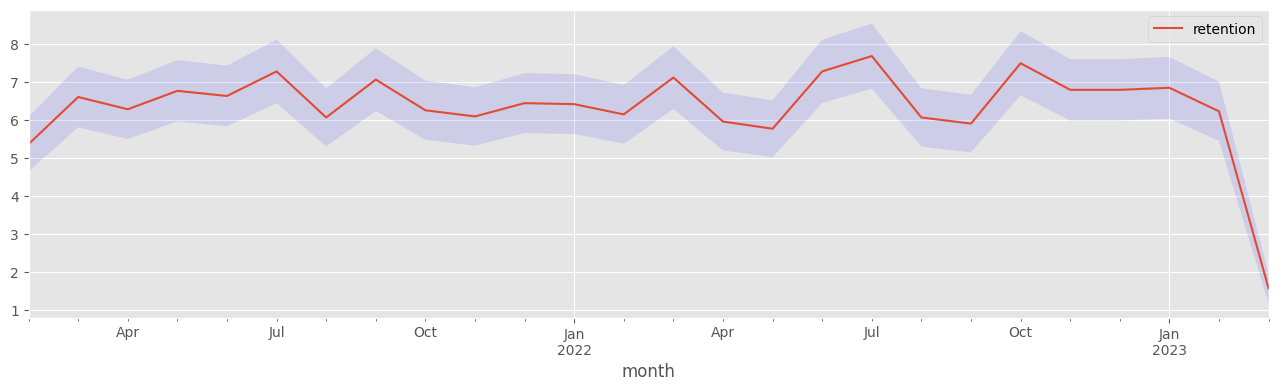

In [30]:
fig, ax = plt.subplots(figsize=(16,4))
retention[['month', 'retention']].plot(x='month', ax=ax)
ax.fill_between(retention['month'], retention['left'], retention['right'], alpha=0.1, facecolor='blue')

## 15. Посчитайте средний доход с пользователя (ARPU) в каждом месяце и доверительные интервалы для него (5 баллов)
ARPU = Average Revenue Per User  
1) Постройте график ARPU для каждого месяца      
2) Добавьте на график область доверительного интервала для каждого месяца

In [31]:
arpu = df

arpu["month"] = pd.to_datetime(arpu["invoice_date"]).dt.to_period('M')

arpu = arpu.groupby(['month', 'customer_id']).agg({"price": 'sum'}).reset_index().groupby('month').agg({'price': ['mean', confidence_interval]})

arpu_by_month = pd.DataFrame()
arpu_by_month['ARPU'] = arpu['price']['mean']
arpu_by_month['left'] = arpu['price']['confidence_interval'].apply(lambda x: x[0])
arpu_by_month['right'] = arpu['price']['confidence_interval'].apply(lambda x: x[1])
arpu_by_month.reset_index(inplace=True)

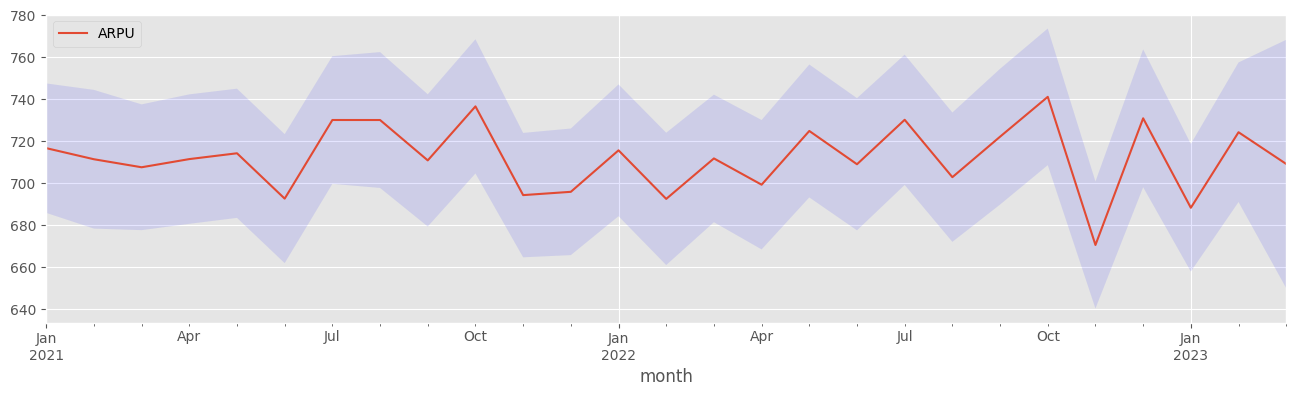

In [32]:
fig, ax = plt.subplots(figsize=(16,4))
arpu_by_month[['month', 'ARPU']].plot(x='month', ax=ax)
plt.fill_between(arpu_by_month['month'], arpu_by_month['left'], arpu_by_month['right'], alpha=0.1, facecolor='blue')